In [148]:
from __future__ import annotations

import os
import sys
from pathlib import Path

import numpy as np
import torch
import matplotlib.pyplot as plt

# Repo root (so `import src...` works in notebook context)
REPO_ROOT = Path.cwd().parent
if str(REPO_ROOT) not in sys.path:
    sys.path.append(str(REPO_ROOT))

from torch_scatter import scatter_mean
from src.model.energy_force_diffusion import EnergyForceDiffusion

# ---- User config ----
CKPT = "/home/iwe67/PycharmProjects/DrugFlow/runs/energy_force_qm9_curated_hjb_fm_woE_leipzighpc_270126/checkpoints/val_loss/epoch_0222_loss_7.165.ckpt"
OUTDIR = Path("examples/notebook_outputs")
OUTDIR.mkdir(parents=True, exist_ok=True)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
DTYPE = torch.float32

print("Repo root:", REPO_ROOT)
print("Using device:", DEVICE)
print("Checkpoint:", CKPT)
print("Output dir:", OUTDIR.resolve())

Repo root: /home/iwe67/PycharmProjects/DrugFlow
Using device: cuda
Checkpoint: /home/iwe67/PycharmProjects/DrugFlow/runs/energy_force_qm9_curated_hjb_fm_woE_leipzighpc_270126/checkpoints/val_loss/epoch_0222_loss_7.165.ckpt
Output dir: /home/iwe67/PycharmProjects/DrugFlow/notebooks/examples/notebook_outputs


In [149]:
# Load model
device = torch.device(DEVICE)
model = EnergyForceDiffusion.load_from_checkpoint(str(CKPT), map_location=device)
model = model.to(device=device, dtype=DTYPE)
model.eval()

print("Allowed atomic numbers:", model.allowed_atomic_numbers)
print("Diffuse h:", model.diffuse_h)
print("Center ligand:", getattr(model, 'center_ligand', True))
print("Default n_steps:", model.n_steps)

Allowed atomic numbers: [1, 6, 7, 8, 9]
Diffuse h: False
Center ligand: True
Default n_steps: 1000


In [150]:
def split_by_batch_mask(data: torch.Tensor, batch_mask: torch.Tensor) -> list[torch.Tensor]:
    # Preserve order within each sample.
    uniques = torch.unique(batch_mask, sorted=True)
    return [data[batch_mask == i] for i in uniques]


def center_by_batch(x: torch.Tensor, batch_mask: torch.Tensor) -> torch.Tensor:
    # Subtract per-molecule COM.
    com = scatter_mean(x, batch_mask, dim=0)
    return x - com[batch_mask]


def write_xyz(out_path: Path, atomic_numbers: np.ndarray, coords: np.ndarray, comment: str = "") -> None:
    if atomic_numbers.shape[0] != coords.shape[0]:
        raise ValueError("atomic_numbers and coords must have same length")

    # XYZ format: N, comment, then "Element x y z".
    try:
        from rdkit import Chem

        periodic_table = Chem.GetPeriodicTable()
        symbols = [periodic_table.GetElementSymbol(int(z)) for z in atomic_numbers]
    except Exception:
        # Fallback: write atomic numbers as symbols.
        symbols = [str(int(z)) for z in atomic_numbers]

    lines: list[str] = [str(len(symbols)), str(comment or "")]
    for sym, (x, y, z) in zip(symbols, coords):
        lines.append(f"{sym} {x:.6f} {y:.6f} {z:.6f}")
    out_path.write_text("\n".join(lines) + "\n")


def one_hot_from_atomic_numbers(
    atomic_numbers: list[int],
    allowed: list[int],
    *,
    device: torch.device,
    dtype: torch.dtype,
) -> torch.Tensor:
    idx = []
    for z in atomic_numbers:
        if int(z) not in allowed:
            raise ValueError(f"Atomic number {z} not in allowed list {allowed}")
        idx.append(allowed.index(int(z)))
    idx = torch.tensor(idx, device=device, dtype=torch.long)
    return torch.nn.functional.one_hot(idx, num_classes=len(allowed)).to(dtype)


@torch.no_grad()
def sample_ligand_with_energy_trace(
    model: EnergyForceDiffusion,
    *,
    n_samples: int,
    num_nodes: int | torch.Tensor,
    timesteps: int | None = None,
    temperature: float | None = None,
    h_sampler: str = "markov_bridge",
    x_sampler: str = "ode",
    atom_type_prior: str = "uniform",
    stochastic_h: bool = False,
    force_steps: int = 0,
    force_lr: float = 1e-4,  # Learning rate for force-guided steps
) -> dict:
    """Mirror `EnergyForceDiffusion.sample_ligand`, but record predicted energies per step."""
    assert x_sampler in {"ode", "sde"}
    assert h_sampler in {"markov_bridge", "score"}

    device = model.device
    dtype = next(model.parameters()).dtype
    timesteps = int(timesteps or model.n_steps)
    if timesteps <= 0:
        raise ValueError("timesteps must be > 0")
    dt = 1.0 / float(timesteps)

    from src.utils import num_nodes_to_batch_mask

    batch_mask = num_nodes_to_batch_mask(n_samples, num_nodes, device=device)
    if batch_mask.numel() == 0:
        raise ValueError("num_nodes produced empty batch_mask")
    sizes = torch.unique(batch_mask, return_counts=True)[1]

    if not model.use_temperature:
        t_temperature = None
    else:
        if temperature is None:
            temperature = float(model.temperature)
        t_temperature = torch.full((n_samples, 1), float(temperature), device=device, dtype=dtype)

    # x at t=0 (noisy prior), with COM=0 for each molecule.
    com = torch.zeros((n_samples, model.x_dim), device=device, dtype=dtype)
    x = model.module_x.sample_z1(com, batch_mask, temperature=t_temperature)

    # h init
    if not model.diffuse_h:
        if atom_type_prior == "uniform":
            idx = torch.randint(model.atom_nf, (batch_mask.shape[0],), device=device)
        else:
            raise ValueError(f"Unsupported atom_type_prior: {atom_type_prior}")
        h = torch.nn.functional.one_hot(idx, num_classes=model.atom_nf).to(dtype)
        h_logits = None
    else:
        if h_sampler == "markov_bridge":
            h = model.module_h.sample_z0(batch_mask)  # one-hot
            h_logits = None
        else:
            h_logits = model.module_h_score.sample_prior(batch_mask, temperature=t_temperature, dtype=dtype)
            h = model.module_h_score.logits_to_probs(h_logits)

    energies = []  # list of (n_samples,)
    times = []

    for i in range(timesteps):
        s_val = 1 - i * dt
        t_val = 1 - (i + 1) * dt
        s = torch.full((n_samples, 1), s_val, device=device, dtype=dtype)
        t = torch.full((n_samples, 1), t_val, device=device, dtype=dtype)

        pred_ligand, _ = model.dynamics(
            x,
            h,
            batch_mask,
            pocket=None,
            t=s,
            temperature=t_temperature,
            bonds_ligand=None,
            sc_transform=None,
        )

        # # Force guidance steps
        # if force_steps > 0:
        #     # Formula provided: F = 2 * (f - v) / g^2
        #     # Assuming f (drift) is 0 for VE SDE.
        #     # v is model prediction (pred_ligand['v'])
        #     # g is diffusion coefficient.
        #     # User specified VE schedule with sigma=5.
        #     # Inverted time: tau = 1 - t (where t is our 's' here, going from 0 to 1).
            
        #     sigma_min = getattr(model, 'sigma_min', 0.01)
        #     sigma_max = getattr(model, 'sigma_max', 5.0)
            
        #     # Current diffusion time 'tau' (standard convention goes 1->0, our 's' goes 0->1)
        #     tau = 1.0 - s_val
            
        #     # g(tau) calculation for VE:
        #     # sigma(tau) = sigma_min * (sigma_max / sigma_min) ** tau
        #     # g(tau)^2 = d(sigma^2)/dtau = 2 * sigma(tau) * sigma'(tau)
        #     # sigma'(tau) = sigma(tau) * ln(sigma_max/sigma_min)
        #     # => g(tau)^2 = 2 * sigma(tau)^2 * ln(sigma_max/sigma_min)
            
        #     sigma_tau = sigma_min * (sigma_max / sigma_min) ** tau
        #     g2 = 2 * (sigma_tau ** 2) * np.log(sigma_max / sigma_min)
            
        #     # v is model output score/velocity.
        #     v = pred_ligand["v"]
        #     f = torch.zeros_like(v) # drift is 0
            
        #     # Force F = 2 * (f - v) / g^2
        #     force = 2 * (f - v) / g2
            
        #     for _ in range(force_steps):
        #         x = x + force_lr * force
                
        #         if getattr(model, "center_ligand", True):
        #             x = center_by_batch(x, batch_mask)
                
        #         # Recalculate force for next step
        #         if _ < force_steps - 1:
        #              pred_refine, _ = model.dynamics(x, h, batch_mask, pocket=None, t=s, temperature=t_temperature, bonds_ligand=None, sc_transform=None)
        #              v_refine = pred_refine["v"]
        #              force = 2 * (f - v_refine) / g2

        if "energy" not in pred_ligand:
            if i == 0: print("Warning: 'energy' not in predictions, filling with 0.0")
            e_graph = torch.zeros(n_samples, device=device, dtype=dtype)
        else:
            e = pred_ligand["energy"].to(dtype=torch.float32).view(-1)
            # Support either per-graph or per-node energy.
            if e.numel() == n_samples:
                e_graph = e
            elif e.numel() == batch_mask.numel():
                e_graph = scatter_mean(e, batch_mask, dim=0)
            else:
                raise ValueError(
                    f"Unexpected energy shape: numel={e.numel()} (expected {n_samples} or {batch_mask.numel()})"
                )

        energies.append(e_graph.detach().cpu().numpy())
        times.append(s_val)

        # Euler step for x: dx/dt = v
        step = (t - s)[batch_mask]
        x = x + step * pred_ligand["v"].to(dtype=x.dtype)

        if getattr(model, "center_ligand", True):
            x = center_by_batch(x, batch_mask)

        # Update h if diffusing
        if model.diffuse_h:
            if h_sampler == "markov_bridge":
                h = model.module_h.sample_zt_given_zs(
                    h,
                    pred_ligand["logits_h"],
                    s=s,
                    t=t,
                    batch_mask=batch_mask,
                )
            else:
                assert h_logits is not None
                if x_sampler == "ode":
                    h_logits = model.module_h_score.ode_step(
                        h_logits,
                        pred_ligand["logits_h"],
                        s=s,
                        t=t,
                        batch_mask=batch_mask,
                        temperature=t_temperature,
                    )
                else:
                    h_logits = model.module_h_score.reverse_step(
                        h_logits,
                        pred_ligand["logits_h"],
                        s=s,
                        t=t,
                        batch_mask=batch_mask,
                        temperature=t_temperature,
                        stochastic=stochastic_h,
                    )
                h = model.module_h_score.logits_to_probs(h_logits)

    # Finalize categorical sample
    if model.diffuse_h and h_sampler == "score":
        idx = torch.argmax(h, dim=-1)
        h = torch.nn.functional.one_hot(idx, num_classes=model.atom_nf).to(h.dtype)

    return {
        "x": x,
        "one_hot": h,
        "mask": batch_mask,
        "size": sizes,
        "energy_trace": np.stack(energies, axis=0),  # (timesteps, n_samples)
        "time_trace": np.array(times, dtype=np.float32),
    }

## Task 1 — Sample a molecule and write `.xyz`
This uses the same sampling loop as `EnergyForceDiffusion.sample_ligand`, and writes an XYZ file to `OUTDIR`.

In [151]:
# Sample 1 molecule (adjust NUM_NODES / TIMESTEPS as desired)
N_SAMPLES = 1
NUM_NODES = 10
TIMESTEPS = 100
FORCE_STEPS = 0
TEMPERATURE = None  # set e.g. 1.0 to override

batch = sample_ligand_with_energy_trace(
    model,
    n_samples=N_SAMPLES,
    num_nodes=NUM_NODES,
    timesteps=TIMESTEPS,
    temperature=TEMPERATURE,
    force_steps=FORCE_STEPS,
    x_sampler='ode',
    h_sampler='markov_bridge',
)

coords_list = split_by_batch_mask(batch['x'].detach().cpu(), batch['mask'].detach().cpu())
onehot_list = split_by_batch_mask(batch['one_hot'].detach().cpu(), batch['mask'].detach().cpu())
allowed_z = torch.tensor(model.allowed_atomic_numbers, dtype=torch.long)

i = 0
coords = coords_list[i].numpy()
idx = torch.argmax(onehot_list[i], dim=-1).to(torch.long)
atomic_numbers = allowed_z[idx].numpy()

stem = f'notebook_sample_{i:04d}_n{coords.shape[0]}'
xyz_path = OUTDIR / f'{stem}.xyz'
write_xyz(xyz_path, atomic_numbers=atomic_numbers, coords=coords, comment=stem)
print('Wrote:', xyz_path.resolve())

Wrote: /home/iwe67/PycharmProjects/DrugFlow/notebooks/examples/notebook_outputs/notebook_sample_0000_n10.xyz


## Task 2 — Plot energy vs timestep during sampling
The plot below shows the model-predicted energy at each reverse step (evaluated at time $s$ before the Euler update).

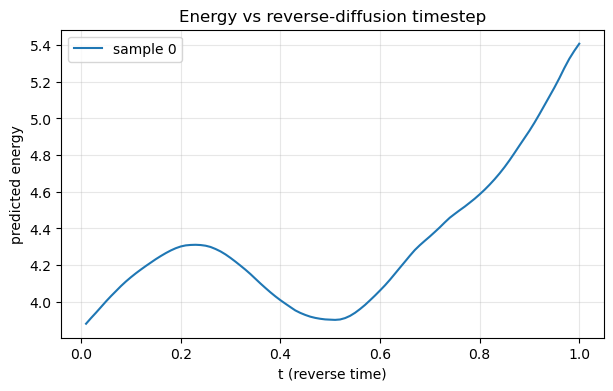

In [152]:
energy_trace = batch['energy_trace']  # (timesteps, n_samples)
time_trace = batch['time_trace']

plt.figure(figsize=(7, 4))
for j in range(energy_trace.shape[1]):
    plt.plot(time_trace, energy_trace[:, j], label=f'sample {j}')
plt.xlabel('t (reverse time)')
plt.ylabel('predicted energy')
plt.title('Energy vs reverse-diffusion timestep')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

## Task 3 — Water displacement energy heatmaps
We build a water molecule (O,H,H), then displace one H atom on an $x$–$y$ grid while keeping $z$ fixed.

To keep this fast, the grid is **batched**: each grid point is treated as a separate 3-atom molecule, so we do one forward pass per requested timestep.

In [153]:
# Define a simple water geometry (Angstrom-ish scale)
water_z = [8, 1, 1]  # O, H1, H2
water_xyz = np.array([
    [0.0000, 0.0000, 0.0000],   # Oxygen at origin
    [0.9572, 0.0000, 0.0000],   # H1
    [-0.2390, 0.9270, 0.0000],  # H2
], dtype=np.float32)

# Displace H1 (index 1) in the x-y plane
# We want to scan the position of H1, while holding O and H2 fixed.
DISPLACE_ATOM_INDEX = 1

# Define the scan area in ABSOLUTE coordinates (Lab Frame)
# Covering enough area to see all atoms
GRID_N = 60
X_SCAN = (-2.0, 2.5)
Y_SCAN = (-2.0, 2.0)

xs = np.linspace(X_SCAN[0], X_SCAN[1], GRID_N, dtype=np.float32)
ys = np.linspace(Y_SCAN[0], Y_SCAN[1], GRID_N, dtype=np.float32)
XX, YY = np.meshgrid(xs, ys, indexing='xy')
grid_points = np.stack([XX.reshape(-1), YY.reshape(-1)], axis=-1)  # (P,2)
P = grid_points.shape[0]

# Prepare batched water molecules: P molecules, each with 3 atoms
base = torch.tensor(water_xyz, device=device, dtype=DTYPE)  # (3,3)
x_batched = base.unsqueeze(0).repeat(P, 1, 1)  # (P,3,3)

# OVERWRITE the position of the moving atom with the grid coordinates
# This ensures the input 'x' corresponds exactly to the grid we are plotting.
x_batched[:, DISPLACE_ATOM_INDEX, 0] = torch.tensor(grid_points[:, 0], device=device, dtype=DTYPE)
x_batched[:, DISPLACE_ATOM_INDEX, 1] = torch.tensor(grid_points[:, 1], device=device, dtype=DTYPE)

# Flatten to node list and make batch mask
x_nodes = x_batched.reshape(P * 3, 3)
batch_mask = torch.repeat_interleave(torch.arange(P, device=device), repeats=3)

# One-hot atom types
h_onehot_single = one_hot_from_atomic_numbers(water_z, model.allowed_atomic_numbers, device=device, dtype=DTYPE)
h_nodes = h_onehot_single.unsqueeze(0).repeat(P, 1, 1).reshape(P * 3, -1)

# Center the batch for the model (Energy is invariant, but model expects zero-COM)
if getattr(model, 'center_ligand', True):
    x_nodes = center_by_batch(x_nodes, batch_mask)

# Timesteps to visualize
TS = [0.0, 0.25, 0.5, 0.75, 1.0]

# Temperature
if not model.use_temperature:
    t_temperature = None
else:
    t_temperature = torch.full((P, 1), float(model.temperature), device=device, dtype=DTYPE)

print(f'Evaluating {P} grid points (GRID_N={GRID_N})...')

Evaluating 3600 grid points (GRID_N=60)...


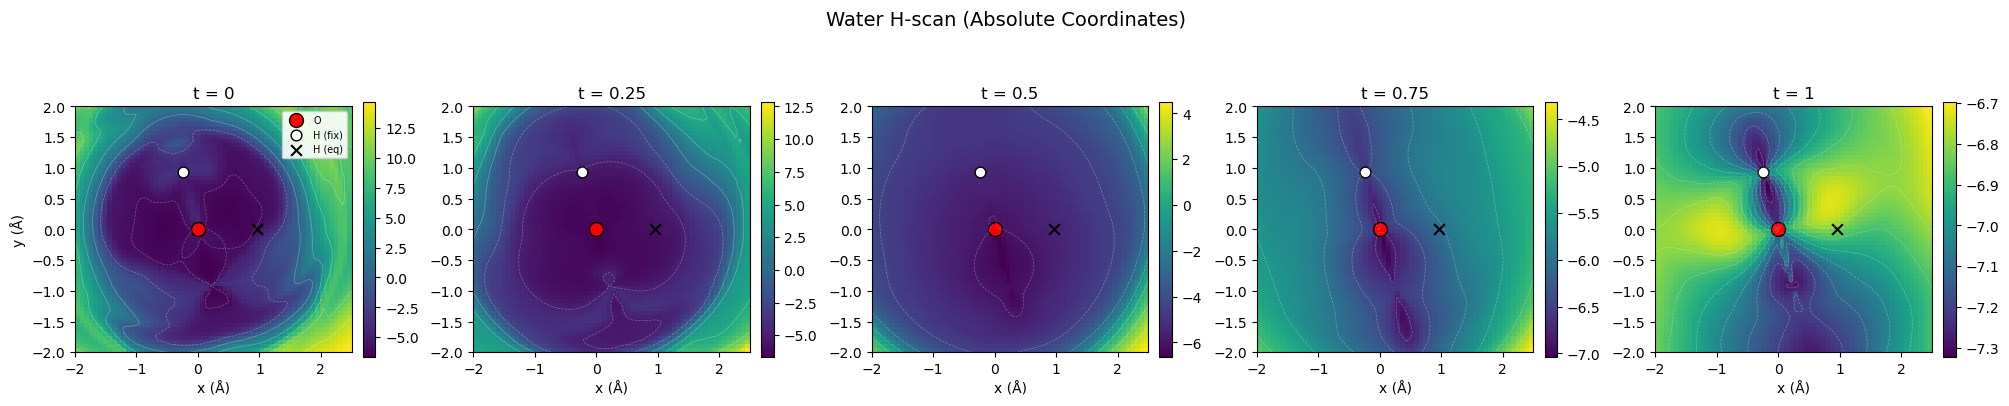

In [154]:
# --- Plotting ---
fig, axes = plt.subplots(1, len(TS), figsize=(4 * len(TS), 4.0), constrained_layout=True)

# Reference atoms in ABSOLUTE coords (for scatter overlay)
ref_ohh = water_xyz[:, :2]

for ax, tval in zip(axes, TS):
    t = torch.full((P, 1), float(tval), device=device, dtype=DTYPE)
    pred, _ = model.dynamics(
        x_nodes, h_nodes, batch_mask, pocket=None, t=t,
        temperature=t_temperature, bonds_ligand=None, sc_transform=None,
    )
    e = pred['energy'].to(dtype=torch.float32).view(-1)

    if e.numel() == P:
        e_graph = e
    elif e.numel() == batch_mask.numel():
        e_graph = scatter_mean(e, batch_mask, dim=0)
    else:
        raise ValueError(f'Unexpected energy shape: {e.numel()}')

    heat = e_graph.detach().cpu().numpy().reshape(GRID_N, GRID_N)

    # Plot using ABSOLUTE coordinates in extent
    im = ax.imshow(
        heat,
        origin='lower',
        extent=(X_SCAN[0], X_SCAN[1], Y_SCAN[0], Y_SCAN[1]),
        aspect='equal', # Ensure physical aspect ratio
        cmap='viridis'
    )

    # Overlay Atoms at their ABSOLUTE positions
    # 1. Oxygen (Fixed at 0,0)
    ax.scatter(ref_ohh[0, 0], ref_ohh[0, 1], c='red', s=100, edgecolors='k', label='O')
    # 2. H2 (Fixed)
    ax.scatter(ref_ohh[2, 0], ref_ohh[2, 1], c='white', s=60, edgecolors='k', label='H (fix)')
    # 3. H1 (Equilibrium position of the moving atom)
    ax.scatter(ref_ohh[1, 0], ref_ohh[1, 1], c='k', marker='x', s=60, label='H (eq)')

    ax.set_title(f't = {tval:g}')
    ax.set_xlabel('x (Å)')
    if ax is axes[0]:
        ax.set_ylabel('y (Å)')
        ax.legend(loc='upper right', fontsize='x-small', framealpha=0.9)

    # Add contour for clarity
    ax.contour(XX, YY, heat, colors='white', alpha=0.3, linewidths=0.5)

    cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    # cbar.set_label('Energy')

plt.suptitle('Water H-scan (Absolute Coordinates)', y=1.05, fontsize=14)
plt.show()

## Task 4 — Boltzmann Distribution Analysis
We sample a larger batch of molecules and analyze the distribution of their final predicted energies. If the generative model has learned to sample from the Boltzmann distribution $p(x) \propto e^{-E(x)/T}$, the tail of the energy histogram should decay exponentially (linear in log-density).


Task 4: Sampling 1024 molecules (n=8) to analyze energy distribution...


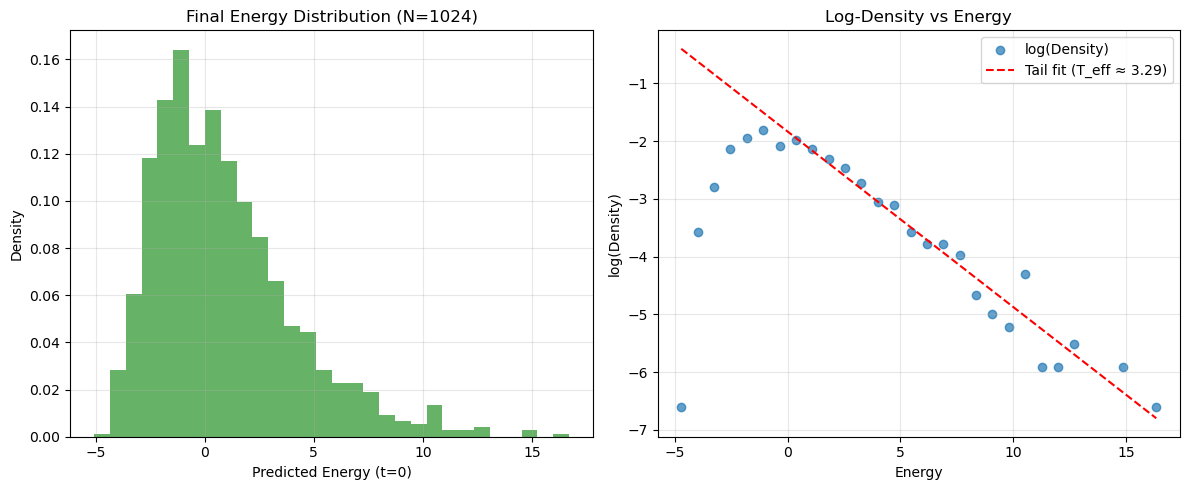

Mean Final Energy: 0.8732 +/- 3.2314
Min: -5.0727, Max: 16.7017


In [155]:
# Task 4 Configuration
T4_N_SAMPLES = 1024
T4_NUM_NODES = 8  # Fixed size for distribution analysis
T4_TIMESTEPS = 50
T4_TEMPERATURE = None  # None uses model default

print(f"Task 4: Sampling {T4_N_SAMPLES} molecules (n={T4_NUM_NODES}) to analyze energy distribution...")

# 1. Generate samples
batch_t4 = sample_ligand_with_energy_trace(
    model,
    n_samples=T4_N_SAMPLES,
    num_nodes=T4_NUM_NODES,
    timesteps=T4_TIMESTEPS,
    temperature=T4_TEMPERATURE,
    x_sampler='ode',
    h_sampler='markov_bridge',
)

# 2. Extract final energies (from the energy trace at the last step, t=0)
# energy_trace shape is (timesteps, n_samples)
# The last entry corresponds to s=0.0 (end of generation)
final_energies = batch_t4['energy_trace'][-1, :]

# 3. Analyze and Plot
from scipy.optimize import curve_fit

def boltzmann_pdf(E, T_eff, C):
    # p(E) ~ exp(-E / T_eff) * g(E) ?
    # Usually we plot histogram of E. If samples x ~ exp(-E(x)/T),
    # the distribution of E values P(E) depends on density of states g(E).
    # P(E) = g(E) exp(-E/T)
    # For a simple harmonic analysis around minima, this looks like a Gamma / Chi-chi dist.
    # But often checking log P(E) vs E linearity is a quick check for Boltzmann tail.
    return C * np.exp(-E / T_eff)

plt.figure(figsize=(12, 5))

# Subplot 1: Histogram
plt.subplot(1, 2, 1)
counts, bins, patches = plt.hist(final_energies, bins=30, density=True, alpha=0.6, color='g', label='Sampled E')
bin_centers = 0.5 * (bins[:-1] + bins[1:])

# Fit exponential tail to the right side of the peak?
# Or just plot simple exponential decay if appropriate.
# Here we just visualize the distribution.
plt.title(f'Final Energy Distribution (N={T4_N_SAMPLES})')
plt.xlabel('Predicted Energy (t=0)')
plt.ylabel('Density')
plt.grid(True, alpha=0.3)

# Subplot 2: Log-prob plot (Boltzmann check)
# If p(x) ~ exp(-E(x)/T), then usually high E tails fall off exponentially.
# log P(E) vs E should be linear with slope -1/T for high E (ignoring DOS effects).
plt.subplot(1, 2, 2)
# Filter bins with non-zero counts
valid = counts > 0
log_counts = np.log(counts[valid])
valid_centers = bin_centers[valid]

plt.scatter(valid_centers, log_counts, alpha=0.7, label='log(Density)')

# Simple linear fit to the tail (e.g. above median energy) to estimate effective T
median_E = np.median(final_energies)
tail_mask = valid_centers > median_E
if tail_mask.sum() > 2:
    slope, intercept = np.polyfit(valid_centers[tail_mask], log_counts[tail_mask], 1)
    T_est = -1.0 / slope
    plt.plot(valid_centers, slope * valid_centers + intercept, 'r--', label=f'Tail fit (T_eff ≈ {T_est:.2f})')

plt.title('Log-Density vs Energy')
plt.xlabel('Energy')
plt.ylabel('log(Density)')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Mean Final Energy: {np.mean(final_energies):.4f} +/- {np.std(final_energies):.4f}")
print(f"Min: {np.min(final_energies):.4f}, Max: {np.max(final_energies):.4f}")